<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/ch5_wave_on_trial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install transformer-lens


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.1 MB/s eta 0:00:00


## The chirp — prediction, locked

Conditional on the wave surviving the axis-split control above.

**Prediction:** the wave is a chirp — short wavelength in early layers,
stretching as depth increases. Operationally: (1) spacing between
consecutive extrema of the detrended mean curve is non-decreasing with
fractional depth (one inversion allowed at n=24); (2) the early-depth
half's spectral centroid sits higher than the late-depth half's.
Both criteria must hold, or the verdict is "not resolved at this depth."

Confidence: certain. Detrending: same quadratic fit as ch4, applied to
the mean curve.


In [ ]:
!pip -q install transformer-lens
import numpy as np, torch, gc
from transformer_lens import HookedTransformer

# ---- axis-building sets, SPLIT BY CONSTRUCTION (not by seed) ----
posA = [
    "The meal at the restaurant was absolutely wonderful.",
    "Her performance in the final act was brilliant.",
    "The weather on the coast stayed lovely all week.",
]
negA = [
    "The meal at the restaurant was absolutely terrible.",
    "Her performance in the final act was dreadful.",
    "The weather on the coast stayed miserable all week.",
]
posB = [
    "The music at the wedding sounded delightful all evening.",
    "The paint on the old fence looked fresh in the sun.",
    "Dinner with her cousins felt wonderful from start to finish.",
]
negB = [
    "The music at the wedding sounded dreadful all evening.",
    "The paint on the old fence looked filthy in the sun.",
    "Dinner with her cousins felt terrible from start to finish.",
]

# ch4's ten test pairs — verbatim
test_pairs = [
    ("The concert in the park sounded wonderful and the crowd stayed late.",
     "The concert in the park sounded terrible and the crowd stayed late."),
    ("Her garden looked beautiful after the rain stopped falling.",
     "Her garden looked dreadful after the rain stopped falling."),
    ("The service at the hotel was excellent and the staff seemed calm.",
     "The service at the hotel was awful and the staff seemed calm."),
    ("His first attempt at the recipe tasted delicious and the kitchen smelled good.",
     "His first attempt at the recipe tasted disgusting and the kitchen smelled good."),
    ("The view from the window seemed lovely in the morning light.",
     "The view from the window seemed miserable in the morning light."),
    ("The lecture on physics felt inspiring and the students asked questions.",
     "The lecture on physics felt tedious and the students asked questions."),
    ("The journey through the mountains was pleasant and the roads stayed clear.",
     "The journey through the mountains was horrible and the roads stayed clear."),
    ("The film about the ocean looked stunning and the music matched well.",
     "The film about the ocean looked boring and the music matched well."),
    ("The bread from the bakery smelled amazing and the queue moved quickly.",
     "The bread from the bakery smelled horrid and the queue moved quickly."),
    ("The report on the findings read brilliant and the figures looked clean.",
     "The report on the findings read hopeless and the figures looked clean."),
]

def flip_and_window(tp, tn):
    if tp.shape != tn.shape: return None, None
    d = (tp[0] != tn[0]).nonzero().flatten()
    if len(d) != 1: return None, None
    f = d.item()
    return f, (f + 1, tp.shape[1])

print("cell 1 loaded:", len(test_pairs), "test pairs,",
      len(posA), "A pairs,", len(posB), "B pairs")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.2 MB/s eta 0:00:00
cell 1 loaded: 10 test pairs, 3 A pairs, 3 B pairs


In [ ]:
name = "pythia-410m"
model = HookedTransformer.from_pretrained_no_processing(name, dtype=torch.float16)
n_layers, d_model = model.cfg.n_layers, model.cfg.d_model

# sanity: all three B pairs MUST print an integer flip position
for sp, sn in zip(posB, negB):
    f, _ = flip_and_window(model.to_tokens(sp), model.to_tokens(sn))
    print("B pair flip at:", f, "|", sp[:40])

def build_axes(pos, neg):
    def all_layer_means(prompts):
        outs = []
        for p in prompts:
            _, c = model.run_with_cache(model.to_tokens(p))
            outs.append(torch.stack([c["resid_post", L][0].mean(dim=0).float()
                                     for L in range(n_layers)]))
        return torch.stack(outs)          # [n_prompts, n_layers, d]
    P_, N_ = all_layer_means(pos), all_layer_means(neg)
    axes = {}
    for L in range(n_layers):
        a = P_[:, L].mean(0) - N_[:, L].mean(0)
        axes[L] = a / a.norm()
    return axes

axesA, axesB = build_axes(posA, negA), build_axes(posB, negB)

# free side-measurement: stability of difference-of-means itself
cos = [(axesA[L] @ axesB[L]).item() for L in range(n_layers)]
print("\naxes-A · axes-B cosine per layer:", np.round(cos, 3))

# run each test pair through the model ONCE, project against both axis sets
def all_curves():
    pa_list, pb_list = [], []
    for s_pos, s_neg in test_pairs:
        tpk, tnk = model.to_tokens(s_pos), model.to_tokens(s_neg)
        f, win = flip_and_window(tpk, tnk)
        if f is None: continue
        _, cp = model.run_with_cache(tpk); _, cn = model.run_with_cache(tnk)
        curveA, curveB = [], []
        for L in range(n_layers):
            dvec = (cp["resid_post", L][0] - cn["resid_post", L][0]).float()
            for ax, curve in [(axesA[L], curveA), (axesB[L], curveB)]:
                on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
                off = (dvec - (dvec @ ax)[:, None] * ax[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
                curve.append(on / off)
        pa_list.append(curveA); pb_list.append(curveB)
        del cp, cn
    return np.array(pa_list), np.array(pb_list)

PA, PB = all_curves()
print("curves:", PA.shape, PB.shape)   # expect (9, 24) each

x = np.linspace(0, 1, n_layers)
detrend = lambda P: np.stack([r - np.polyval(np.polyfit(x, r, 2), x) for r in P])
RA, RB = detrend(PA), detrend(PB)

within = lambda R: np.mean([np.corrcoef(R[i], R[j])[0, 1]
                            for i in range(len(R)) for j in range(i + 1, len(R))])
cross_pairs = np.mean([np.corrcoef(RA[i], RB[i])[0, 1] for i in range(len(RA))])
mA, mB = RA.mean(0), RB.mean(0)
cross_mean = np.corrcoef(mA - np.polyval(np.polyfit(x, mA, 2), x),
                         mB - np.polyval(np.polyfit(x, mB, 2), x))[0, 1]

print(f"\nwithin-A: {within(RA):.3f}   within-B: {within(RB):.3f}")
print(f"cross-AB (per-pair): {cross_pairs:.3f}")
print(f"cross-AB (mean curves): {cross_mean:.3f}   <-- the verdict number")
del model; gc.collect(); torch.cuda.empty_cache()


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m into HookedTransformer
B pair flip at: 6 | The music at the wedding sounded delight
B pair flip at: 7 | The paint on the old fence looked fresh 
B pair flip at: 6 | Dinner with her cousins felt wonderful f

axes-A · axes-B cosine per layer: [0.54  0.51  0.514 0.52  0.517 0.655 0.655 0.638 0.685 0.683 0.727 0.725
 0.756 0.815 0.733 0.739 0.725 0.705 0.706 0.671 0.696 0.698 0.709 0.708]
curves: (9, 24) (9, 24)

within-A: 0.781   within-B: 0.856
cross-AB (per-pair): 0.925
cross-AB (mean curves): 0.960   <-- the verdict number


Verdict: survived — the wave is the network’s. Axes built from disjoint sentence sets (per-layer cosine 0.51–0.82; the axes genuinely differ, especially early) produce the same wave: cross-AB correlation of detrended mean curves = 0.96, per-pair 0.925, against within-group 0.78/0.86. The undulation is not axis-estimation noise. Side-finding: difference-of-means directions from three-sentence sets agree only ~0.5 in early layers, converging to ~0.7–0.8 deep — the feature direction itself sharpens with depth, and the axis-agreement peak (0.815) lands on layer 13, the anomaly layer. Caveats: one model (410m), axes share a common component (cos > 0), n=9 pairs, single detrending recipe.

In [ ]:
from scipy.signal import argrelextrema

# the wave, built from PA (ch4-continuous axis set)
mean_curve = PA.mean(0)
w = mean_curve - np.polyval(np.polyfit(x, mean_curve, 2), x)

# --- Check 1: extrema spacing non-decreasing with depth ---
peaks = argrelextrema(w, np.greater)[0]
troughs = argrelextrema(w, np.less)[0]
ext = np.sort(np.concatenate([peaks, troughs]))
spacing = np.diff(x[ext])
print("extrema at depths:", x[ext].round(2))
print("spacings:", spacing.round(3))
print("non-decreasing (1 inversion allowed):",
      int(np.sum(np.diff(spacing) < -1e-9)), "inversions")

# --- Check 2: two-bin spectral comparison ---
half = len(w) // 2
for nm, seg in [("early", w[:half]), ("late", w[half:])]:
    p = np.abs(np.fft.rfft(seg - seg.mean()))**2
    centroid = (np.arange(len(p)) * p).sum() / p.sum()
    print(f"{nm}: spectral centroid = {centroid:.2f}")
print("(chirp: early > late)")


extrema at depths: [0.09 0.13 0.17 0.22 0.39 0.43 0.48 0.57 0.61 0.65 0.7  0.74 0.91]
spacings: [0.043 0.043 0.043 0.174 0.043 0.043 0.087 0.043 0.043 0.043 0.043 0.174]
non-decreasing (1 inversion allowed): 2 inversions
early: spectral centroid = 3.15
late: spectral centroid = 3.71
(chirp: early > late)


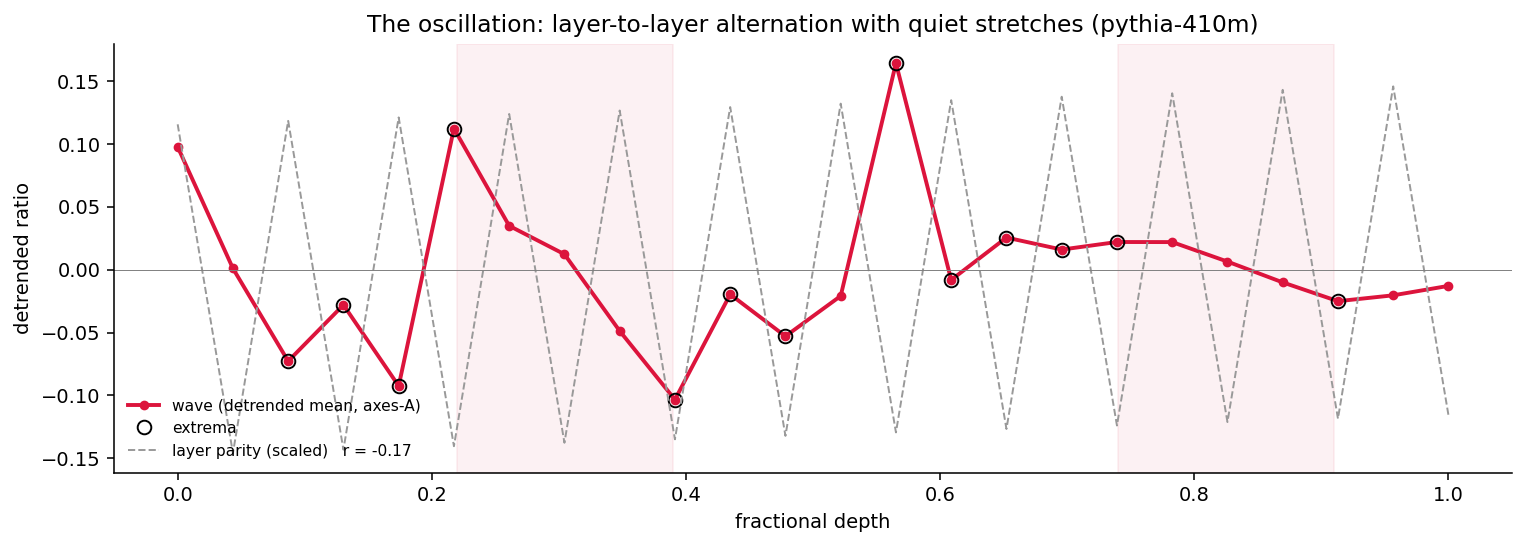

wave · layer-parity correlation: r = -0.171


In [ ]:
import matplotlib.pyplot as plt

parity = (-1.0)**np.arange(n_layers)
parity_d = parity - np.polyval(np.polyfit(x, parity, 2), x)
r_parity = np.corrcoef(w, parity_d)[0, 1]

fig, ax = plt.subplots(figsize=(11, 4), dpi=140)
ax.plot(x, w, 'o-', color='#dc143c', lw=2, ms=4, label='wave (detrended mean, axes-A)')
ax.plot(x[ext], w[ext], 'o', color='black', ms=7, mfc='none', label='extrema')
ax.plot(x, parity_d * np.abs(w).max()*0.8, '--', color='#999999', lw=1,
        label=f'layer parity (scaled)   r = {r_parity:.2f}')
ax.axhline(0, color='gray', lw=0.5)
# mark the two quiet stretches
for a, b in [(0.22, 0.39), (0.74, 0.91)]:
    ax.axvspan(a, b, color='#dc143c', alpha=0.06)
ax.set_xlabel("fractional depth"); ax.set_ylabel("detrended ratio")
ax.set_title("The oscillation: layer-to-layer alternation with quiet stretches (pythia-410m)")
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("oscillation_410m.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print(f"wave · layer-parity correlation: r = {r_parity:.3f}")


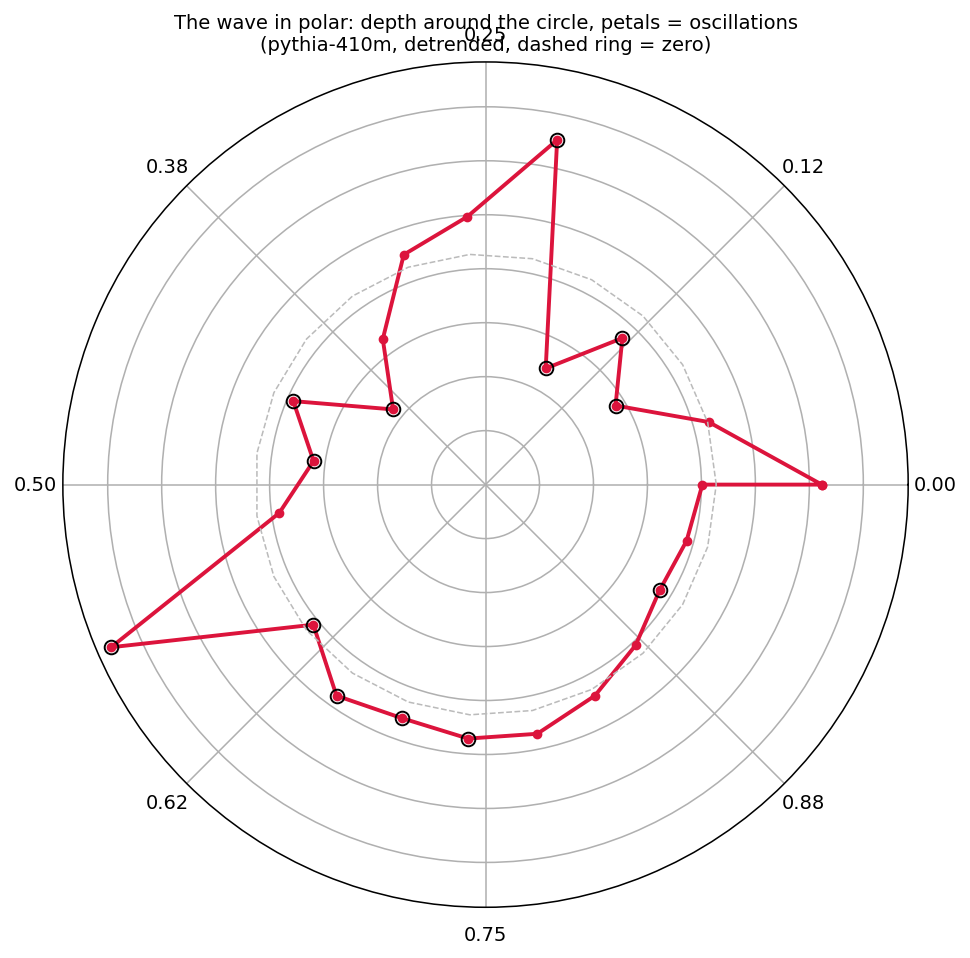

In [ ]:
theta = x * 2*np.pi                      # depth wrapped around the circle
r0 = np.abs(w).max() * 1.3               # baseline ring so negative values stay visible
r = r0 + w

fig = plt.figure(figsize=(7, 7), dpi=140)
ax = fig.add_subplot(111, projection='polar')
ax.plot(np.append(theta, theta[0]+2*np.pi), np.append(r, r[0]),
        '-o', color='#dc143c', lw=2, ms=4)
ax.plot(theta, np.full_like(theta, r0), '--', color='#bbbbbb', lw=0.8)  # zero ring
ax.plot(theta[ext], r[ext], 'o', color='black', ms=7, mfc='none')
ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels([f"{d:.2f}" for d in np.linspace(0, 1, 8, endpoint=False)])
ax.set_yticklabels([])
ax.set_title("The wave in polar: depth around the circle, petals = oscillations\n(pythia-410m, detrended, dashed ring = zero)",
             fontsize=10)
plt.tight_layout()
plt.savefig("wave_flower_410m.png", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()


## The spin — prediction, locked

The polar view appears to rotate clockwise. Translation: the oscillation's
period is not exactly 2 layers; its phase drifts against the layer grid.

**Prediction:** the unwrapped Hilbert phase deviates systematically from the
pure 2-layer reference; mean period ≠ 2.00 layers. Verdict read from the
mean slope and loud regions only — instantaneous frequency inside the two
quiet stretches is ill-defined (amplitude ≈ 0) and does not count either way.

Confidence: certain.


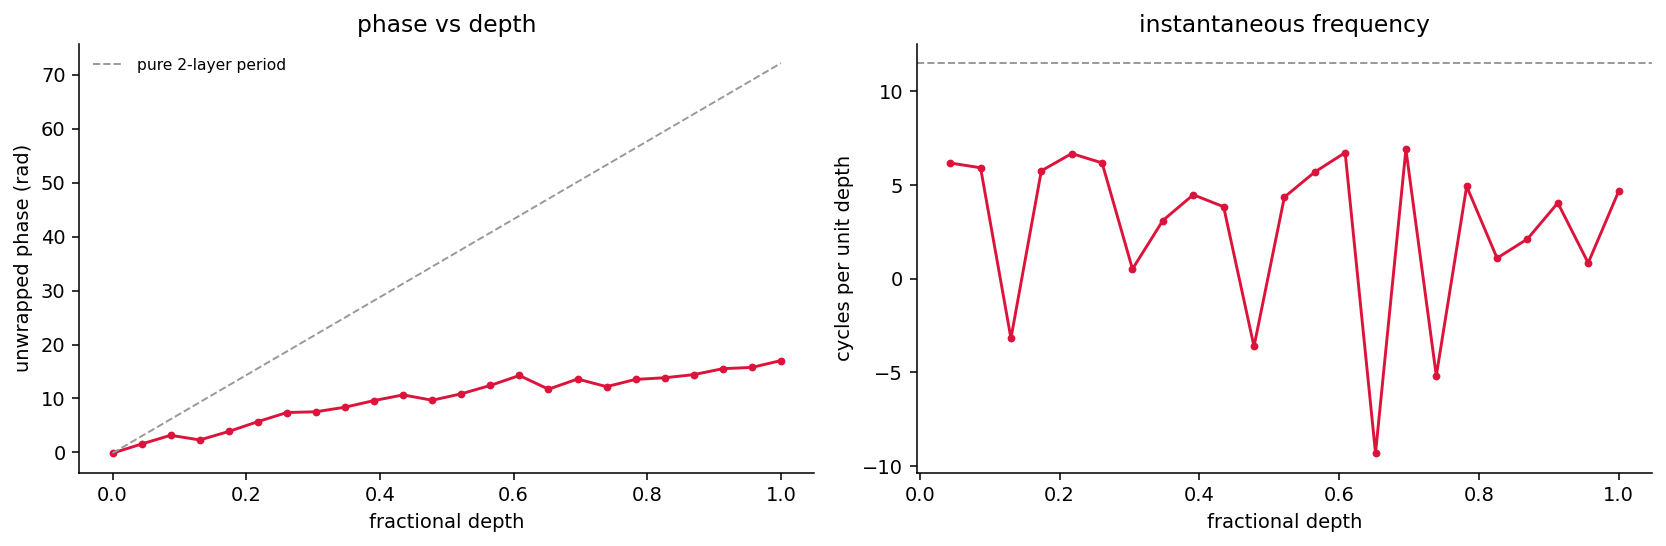

mean period: 8.43 layers   (spin ⇔ period ≠ 2.00)


In [ ]:
from scipy.signal import hilbert

analytic = hilbert(w)
phase = np.unwrap(np.angle(analytic))
inst_freq = np.diff(phase) / np.diff(x)          # radians per unit depth

fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=140)
ax[0].plot(x, phase, 'o-', color='#dc143c', ms=3)
# reference: pure period-2-layer oscillation would climb at pi per layer step
ax[0].plot(x, phase[0] + np.pi * 23 * x, '--', color='#999999', lw=1,
           label='pure 2-layer period')
ax[0].set_xlabel("fractional depth"); ax[0].set_ylabel("unwrapped phase (rad)")
ax[0].legend(fontsize=8, frameon=False); ax[0].set_title("phase vs depth")

ax[1].plot(x[1:], inst_freq / (2*np.pi), 'o-', color='#dc143c', ms=3)
ax[1].axhline(23/2, color='#999999', ls='--', lw=1)   # 2-layer period line
ax[1].set_xlabel("fractional depth"); ax[1].set_ylabel("cycles per unit depth")
ax[1].set_title("instantaneous frequency")
for a in ax: a.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

period_layers = 2*np.pi / np.mean(inst_freq) * 23
print(f"mean period: {period_layers:.2f} layers   (spin ⇔ period ≠ 2.00)")


**Verdict: survived — the spin is real, and it reframed the wave.** Mean
period 8.43 layers — not a per-layer zigzag with drift, but a slow
oscillation completing roughly three cycles across the network's full depth,
with fast small alternations riding on top. This is what confused every
earlier instrument: the extrema count saw the fast ripple, the parity test
correctly rejected period-2, and the two-bin spectral check averaged both
scales together. The unwrapped phase is nearly straight — the slow
oscillation holds a stable frequency across depth. The two quiet stretches
appear as small phase wobbles; the instantaneous-frequency spike at ~0.65
is the pre-excluded low-amplitude artifact and does not count.

Reframed finding: the concentration ratio oscillates with a period of
roughly one third of network depth — concentrate, redistribute,
concentrate — and nine unrelated sentences ride the same three swings
(cross-AB 0.96). Caveats: one model (410m), 24 samples, Hilbert phase on a
short noisy signal; the period estimate is a mean slope, not a fitted
model; whether the period is fixed in fractional depth or absolute layers
is untested — that is the next locked question.


## Three breaths — prediction, locked

The 410m wave completes ~3 cycles across full network depth (period 8.43
layers ≈ 0.35 fractional). Question: is the period fixed in *fractional
depth* or in *absolute layers*?

**Prediction: fractional.** Pythia-160m (12 layers) and Pythia-1B (16
layers) each complete ~3 cycles — approximately 4 and 5.3 layers per cycle
respectively — rather than holding an ~8-layer absolute period (which would
give 160m ~1.5 cycles and 1B ~2).

Verdict read from mean Hilbert phase slope, loud regions; 160m's 12 samples
is brutally coarse — a cycle count between the two hypotheses' predictions
(e.g. ~2–2.5 for 160m) reads as "not resolved," not as a win for either.



In [ ]:
from scipy.signal import hilbert

pos_matched = posA + [
    "His speech at the ceremony sounded inspiring.",
    "The ending of the novel felt satisfying.",
]
neg_matched = negA + [
    "His speech at the ceremony sounded tedious.",
    "The ending of the novel felt hollow.",
]

for name in ["pythia-160m", "pythia-1b"]:
    model = HookedTransformer.from_pretrained_no_processing(name, dtype=torch.float16)
    nL = model.cfg.n_layers

    def all_layer_means(prompts):
        outs = []
        for p in prompts:
            _, c = model.run_with_cache(model.to_tokens(p))
            outs.append(torch.stack([c["resid_post", L][0].mean(dim=0).float()
                                     for L in range(nL)]))
        return torch.stack(outs)

    Pm, Nm = all_layer_means(pos_matched), all_layer_means(neg_matched)
    axs_ = {L: (lambda a: a / a.norm())(Pm[:, L].mean(0) - Nm[:, L].mean(0))
            for L in range(nL)}

    per_pair = []
    for s_pos, s_neg in test_pairs:
        tpk, tnk = model.to_tokens(s_pos), model.to_tokens(s_neg)
        f, win = flip_and_window(tpk, tnk)
        if f is None: continue
        _, cp = model.run_with_cache(tpk); _, cn = model.run_with_cache(tnk)
        curve = []
        for L in range(nL):
            dvec = (cp["resid_post", L][0] - cn["resid_post", L][0]).float()
            ax = axs_[L]
            on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
            off = (dvec - (dvec @ ax)[:, None] * ax[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
            curve.append(on / off)
        per_pair.append(curve); del cp, cn

    Pmod = np.array(per_pair)
    xm = np.linspace(0, 1, nL)
    wm = Pmod.mean(0) - np.polyval(np.polyfit(xm, Pmod.mean(0), 2), xm)

    phase = np.unwrap(np.angle(hilbert(wm)))
    cycles = (phase[-1] - phase[0]) / (2 * np.pi)
    period_layers = (nL - 1) / cycles if cycles > 0 else float('inf')
    print(f"{name}: {nL} layers | cycles across depth = {cycles:.2f} "
          f"| period = {period_layers:.2f} layers ({period_layers/(nL-1):.2f} fractional)")

    del model, axs_; gc.collect(); torch.cuda.empty_cache()

print("\n410m reference: 24 layers | cycles ≈ 2.7 | period 8.43 layers (0.37 fractional)")
print("Three-breaths predicts cycles ≈ 3 for both. Absolute-8 predicts ~1.4 (160m) and ~1.9 (1B).")


config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model pythia-1b into HookedTransformer
pythia-1b: 16 layers | cycles across depth = 2.71 | period = 5.53 layers (0.37 fractional)

410m reference: 24 layers | cycles ≈ 2.7 | period 8.43 layers (0.37 fractional)
Three-breaths predicts cycles ≈ 3 for both. Absolute-8 predicts ~1.4 (160m) and ~1.9 (1B).


**Verdict: survived — the period is fractional.** Pythia-160m (12 layers):
2.65 cycles, fractional period 0.38. Pythia-1B (16 layers): 2.71 cycles,
0.37. Pythia-410m reference (24 layers): ~2.7 cycles, 0.37. Three model
depths, one number: the network completes roughly 2.7 oscillations across
its depth regardless of layer count — the absolute-period hypothesis
(~8 layers, predicting 1.4 and 1.9 cycles) is dead by a factor of two.
The rhythm is architectural-relative: depth is divided into the same
phases whatever the layer budget, consistent with the assembly-distance
picture in which features organize by fractional depth.

Caveats: same nine sentence pairs and detrend recipe throughout; Hilbert
phase on 12–24 samples is coarse; 70m untested (six layers cannot resolve
the wave, per ch4); one feature, one model family; ~2.7 is a mean slope,
not a fitted frequency.


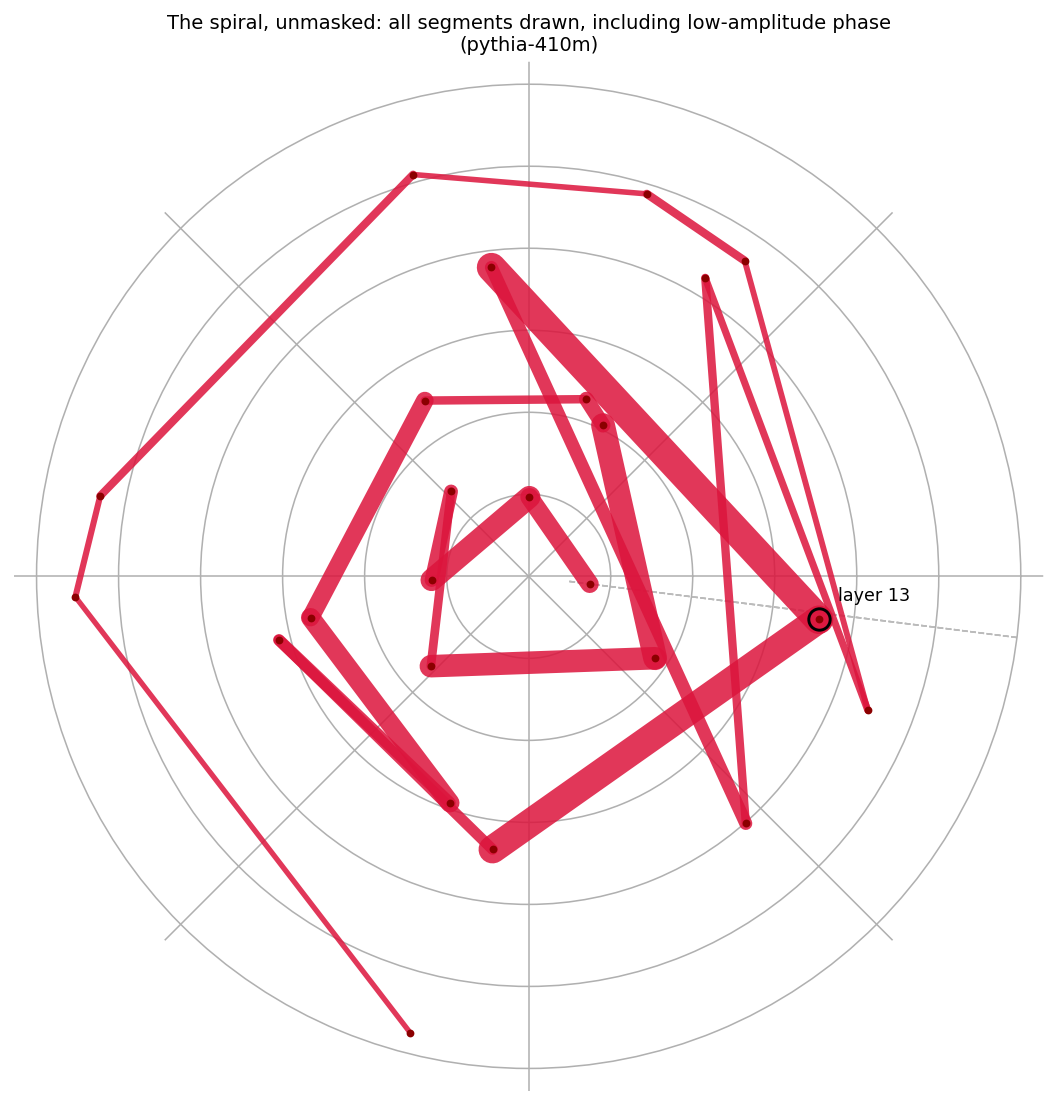

In [11]:
fig = plt.figure(figsize=(8, 8), dpi=140)
ax = fig.add_subplot(111, projection='polar')
for i in range(len(x) - 1):
    ax.plot(phase[i:i+2], r[i:i+2], '-', color='#dc143c',
            lw=1 + 14 * (amp[i] / amp.max()), solid_capstyle='round', alpha=0.85)
ax.plot(phase, r, 'o', color='#8b0000', ms=3, zorder=5)
for k in range(1, int(np.ceil((phase[-1] - phase[0]) / (2*np.pi))) + 1):
    ax.plot([phase[0] + 2*np.pi*k]*2, [0.1, 1.2], '--', color='#bbbbbb', lw=0.8, zorder=1)
ax.plot(phase[13], r[13], 'o', ms=11, mfc='none', mec='black', mew=1.5, zorder=6)
ax.annotate("layer 13", (phase[13], r[13]), textcoords="offset points", xytext=(10, 10), fontsize=9)
ax.set_yticklabels([]); ax.set_xticklabels([])
ax.spines['polar'].set_visible(False)
ax.set_title("The spiral, unmasked: all segments drawn, including low-amplitude phase\n(pythia-410m)", fontsize=10)
plt.tight_layout()
plt.savefig("wave_spiral_unmasked_410m.PNG", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()


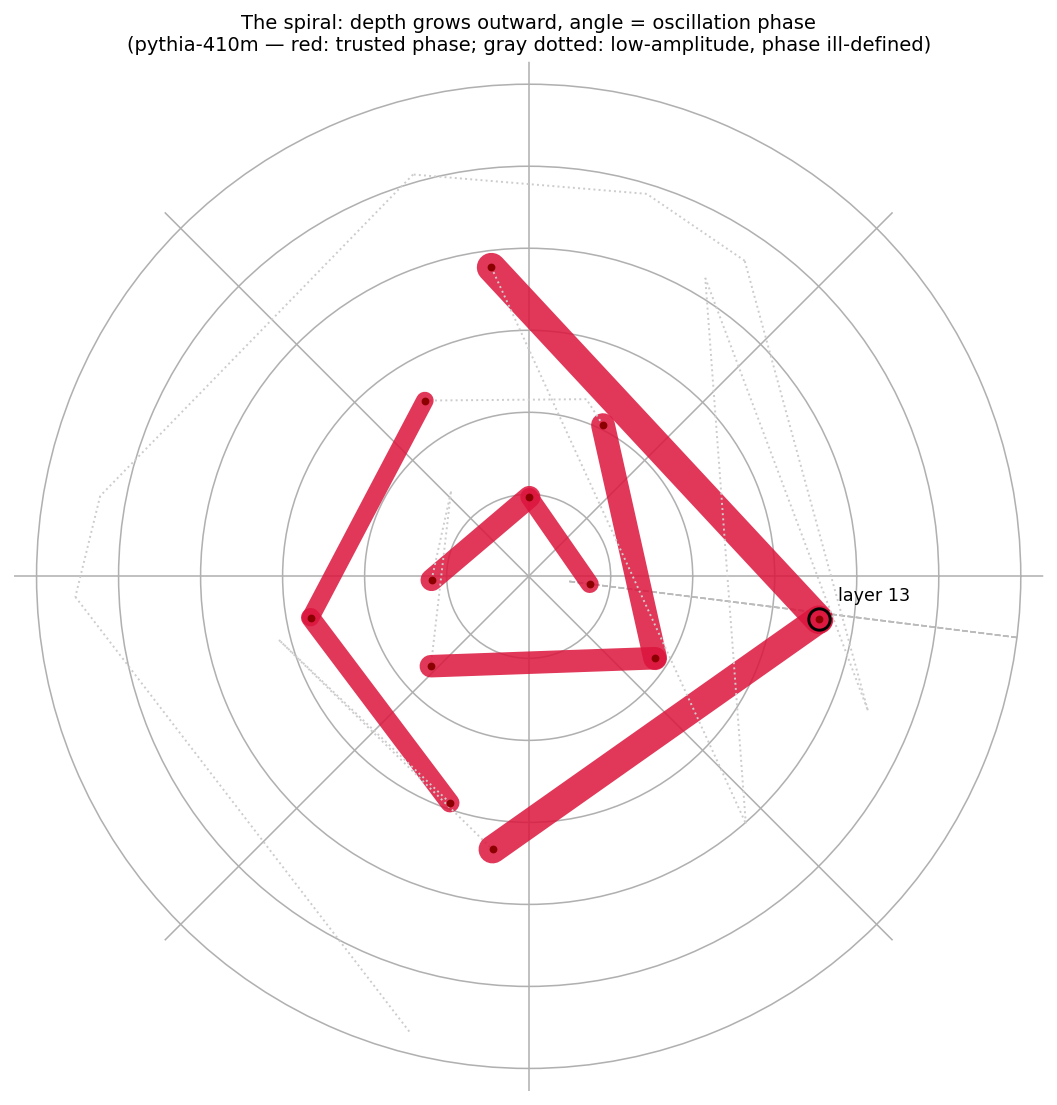

In [12]:
from scipy.signal import hilbert
import matplotlib.pyplot as plt

analytic = hilbert(w)
phase = np.unwrap(np.angle(analytic))
amp = np.abs(analytic)
r = 0.15 + x                                    # radius = depth, growing outward

trust = amp > 0.35 * amp.max()                  # phase only meaningful where the wave is loud

fig = plt.figure(figsize=(8, 8), dpi=140)
ax = fig.add_subplot(111, projection='polar')

for i in range(len(x) - 1):
    if trust[i] and trust[i+1]:
        ax.plot(phase[i:i+2], r[i:i+2], '-', color='#dc143c',
                lw=1 + 14 * (amp[i] / amp.max()), solid_capstyle='round', alpha=0.85)
    else:
        ax.plot(phase[i:i+2], r[i:i+2], ':', color='#cccccc', lw=1)

ax.plot(phase[trust], r[trust], 'o', color='#8b0000', ms=3, zorder=5)

# rays at each completed cycle
for k in range(1, int(np.ceil((phase[-1] - phase[0]) / (2*np.pi))) + 1):
    ax.plot([phase[0] + 2*np.pi*k]*2, [0.1, 1.2], '--', color='#bbbbbb', lw=0.8, zorder=1)

# landmark: layer 13
i13 = 13
ax.plot(phase[i13], r[i13], 'o', ms=11, mfc='none', mec='black', mew=1.5, zorder=6)
ax.annotate("layer 13", (phase[i13], r[i13]), textcoords="offset points",
            xytext=(10, 10), fontsize=9)

ax.set_yticklabels([]); ax.set_xticklabels([])
ax.spines['polar'].set_visible(False)
ax.set_title("The spiral: depth grows outward, angle = oscillation phase\n"
             "(pythia-410m — red: trusted phase; gray dotted: low-amplitude, phase ill-defined)",
             fontsize=10)
plt.tight_layout()
plt.savefig("wave_spiral_410m.PNG", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()


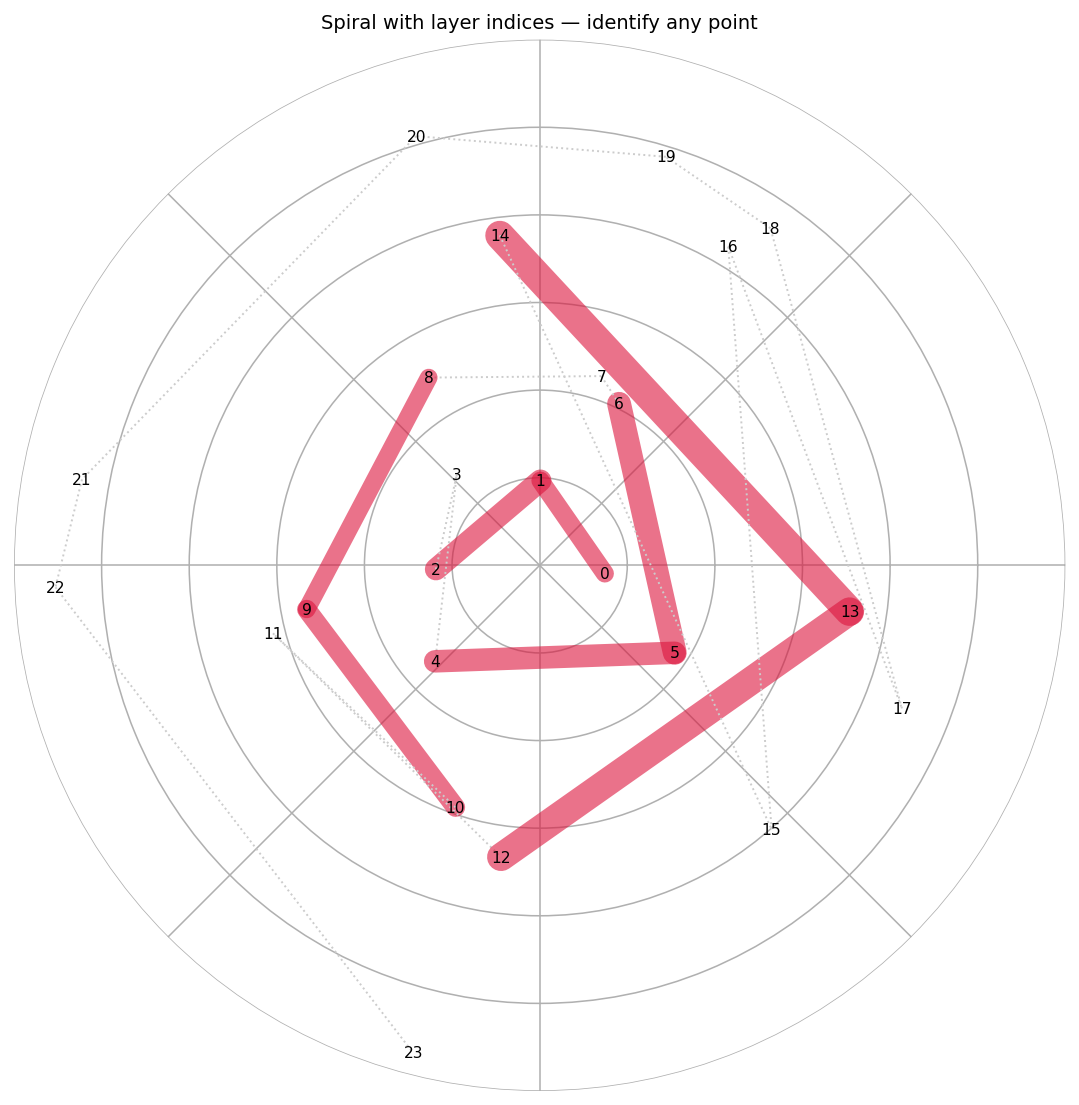

layer 0: depth 0.00 | wave +0.098 | phase -0.12 rad | amp 0.099
layer 1: depth 0.04 | wave +0.001 | phase 1.56 rad | amp 0.123
layer 2: depth 0.09 | wave -0.073 | phase 3.18 rad | amp 0.073
layer 3: depth 0.13 | wave -0.028 | phase 2.31 rad | amp 0.041
layer 4: depth 0.17 | wave -0.093 | phase 3.88 rad | amp 0.126
layer 5: depth 0.22 | wave +0.112 | phase 5.71 rad | amp 0.134


In [13]:
fig = plt.figure(figsize=(8, 8), dpi=140)
ax = fig.add_subplot(111, projection='polar')
for i in range(len(x) - 1):
    if trust[i] and trust[i+1]:
        ax.plot(phase[i:i+2], r[i:i+2], '-', color='#dc143c',
                lw=1 + 14*(amp[i]/amp.max()), solid_capstyle='round', alpha=0.6)
    else:
        ax.plot(phase[i:i+2], r[i:i+2], ':', color='#cccccc', lw=1)
for i in range(len(x)):
    ax.annotate(str(i), (phase[i], r[i]), fontsize=8, ha='center', va='center',
                color='black', zorder=10)
ax.set_yticklabels([]); ax.set_xticklabels([])
ax.spines['polar'].set_visible(False)
ax.set_title("Spiral with layer indices — identify any point", fontsize=10)
plt.tight_layout(); plt.show()

# and the raw record for the early layers:
for i in range(6):
    print(f"layer {i}: depth {x[i]:.2f} | wave {w[i]:+.3f} | phase {phase[i]:.2f} rad | amp {amp[i]:.3f}")


*Unmasked*: all 24 segments drawn. The winding is the measured ~2.7-cycle phase accumulation rendered in polar form — but some continuity here is contributed by low-amplitude segments where instantaneous phase is ill-defined.
Masked: the same spiral with untrusted segments (amplitude < 35% of max) dotted gray. The turning that survives is the rhythm where the wave is loud; the gaps are the quiet stretches.

## The envelope — prediction, locked

The spiral's "snail" quality has one data-legitimate translation: does the
oscillation's amplitude grow by a constant *ratio* per cycle (geometric /
log-spiral envelope) rather than a constant amount (linear) or no trend?

**Test:** regress log(amplitude) on unwrapped phase, trusted (loud) regions
only. Geometric growth ⇒ good linear fit (r² high), slope = log growth-rate
per radian; growth factor per full cycle = exp(2π·slope).

**Prediction:** [your call — geometric, linear, or no law]
Confidence: [your stake]


log-amplitude vs phase:  slope = -0.0053 /rad   r² = 0.005
growth factor per full cycle: ×0.97
(geometric law needs high r²; ×1.00 = flat envelope, no growth)


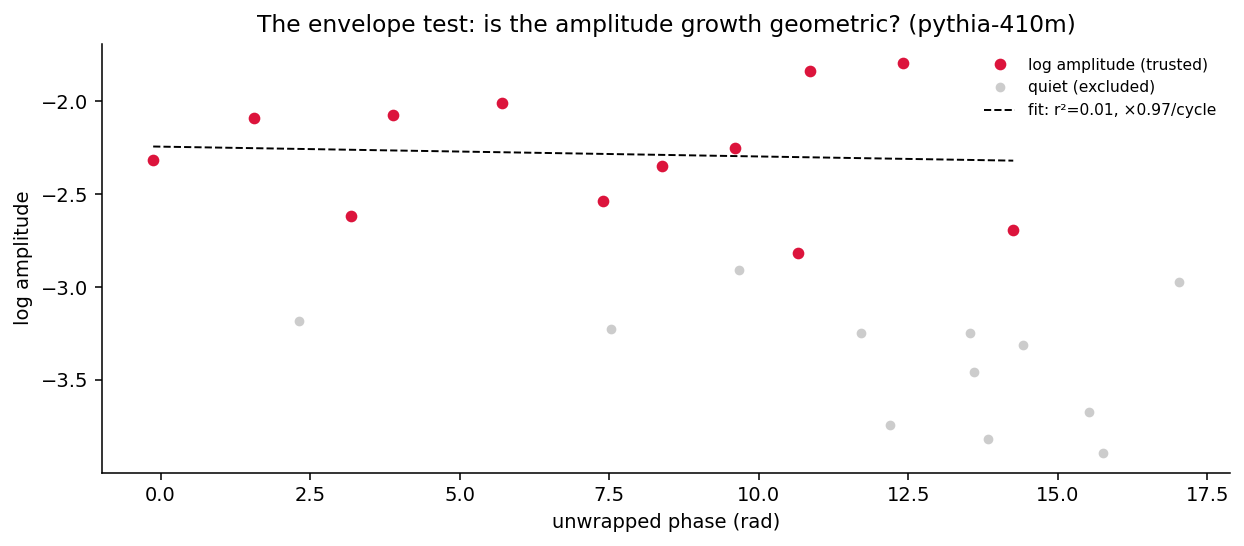

In [14]:
from scipy import stats

mask = trust.copy()                      # loud regions only; phase is junk elsewhere
ph_t, amp_t = phase[mask], amp[mask]

res = stats.linregress(ph_t, np.log(amp_t))
growth_per_cycle = np.exp(res.slope * 2 * np.pi)

print(f"log-amplitude vs phase:  slope = {res.slope:+.4f} /rad   r² = {res.rvalue**2:.3f}")
print(f"growth factor per full cycle: ×{growth_per_cycle:.2f}")
print(f"(geometric law needs high r²; ×1.00 = flat envelope, no growth)")

fig, ax = plt.subplots(figsize=(9, 4), dpi=140)
ax.plot(ph_t, np.log(amp_t), 'o', color='#dc143c', ms=5, label='log amplitude (trusted)')
ax.plot(phase[~mask], np.log(amp[~mask]), 'o', color='#cccccc', ms=4, label='quiet (excluded)')
ax.plot(ph_t, res.intercept + res.slope * ph_t, '--', color='black', lw=1,
        label=f'fit: r²={res.rvalue**2:.2f}, ×{growth_per_cycle:.2f}/cycle')
ax.set_xlabel("unwrapped phase (rad)"); ax.set_ylabel("log amplitude")
ax.set_title("The envelope test: is the amplitude growth geometric? (pythia-410m)")
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("envelope_test_410m.PNG", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()


**Verdict: killed — no growth law.** log-amplitude vs phase: r² = 0.005,
growth ×0.97/cycle. The amplitude bears no relationship to phase; the
log-spiral impression came from the plot's radius mapping (radius = depth
by construction), not from the data. What stands instead: trusted
amplitudes sit in a tight band with no trend — the oscillation runs at
roughly constant loudness where it runs at all, interrupted by quiet
stretches. The envelope is gated, not growing.


## The tense test — prediction, locked

Chapter 4's queued question: if the wave is the network's rhythm rather
than sentiment's property, a second feature should breathe at the same
depths.

**Prediction: same rhythm, same phase.** The tense axis (past/present,
ch2 recipe) produces a depth-wave whose detrended curve correlates
positively and strongly with sentiment's wave on pythia-410m — matched
crests and troughs, not merely matched period. Operationally: r(tense
wave, sentiment wave) is high and positive; Hilbert period lands near
0.37 fractional; phase offset between the two waves is near zero (well
under a quarter-cycle, |Δφ| < π/2).

Confidence: [stake]


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m into HookedTransformer
skipped (tokenization): The gardener watered the plants and the 
tense pairs used: 8/9

r(sentiment wave, tense wave) = 0.008
tense cycles across depth = 2.73  (sentiment: ~2.7)
mean phase offset = +1.15 rad  (0.37·π; prediction: |Δφ| < π/2)


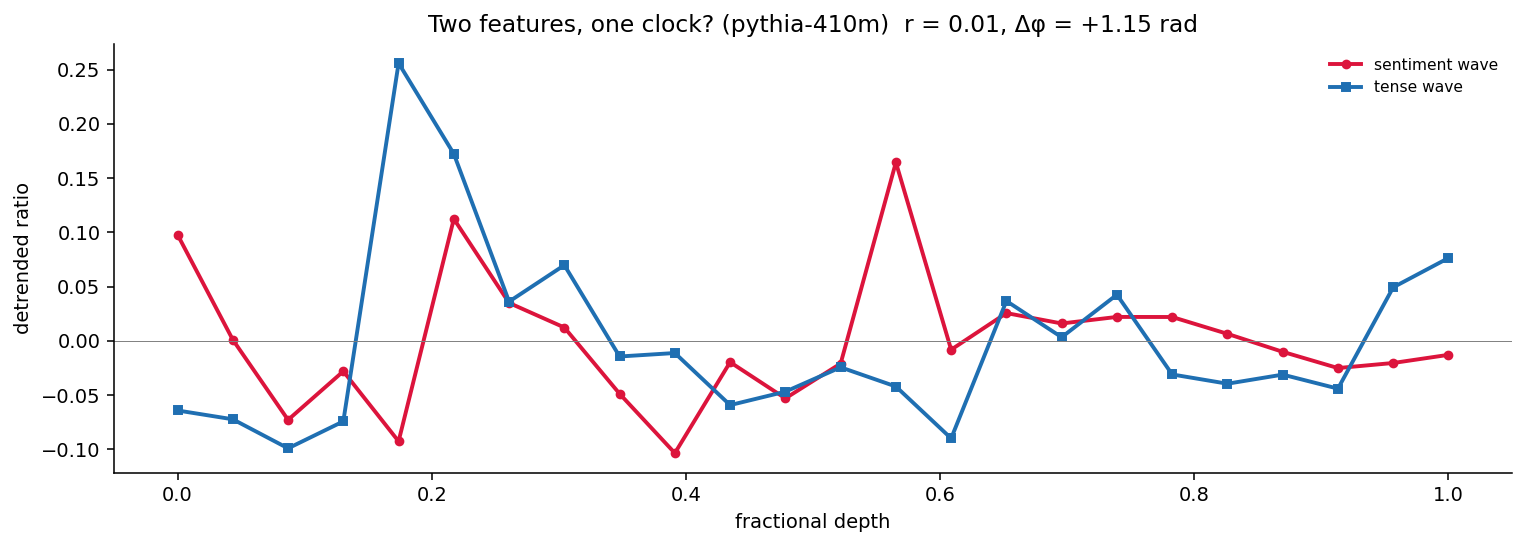

In [15]:
# tense axis-building sets (ch2 recipe)
past_ax = [
    "She walked to the station and caught the early train.",
    "They finished the project and celebrated last night.",
    "He wrote the letter and posted it yesterday morning.",
    "We visited the museum and admired the old paintings.",
    "I cooked dinner and washed the dishes afterwards.",
]
pres_ax = [
    "She walks to the station and catches the early train.",
    "They finish the project and celebrate tonight.",
    "He writes the letter and posts it this morning.",
    "We visit the museum and admire the old paintings.",
    "I cook dinner and wash the dishes afterwards.",
]

# tense TEST pairs — one verb flipped, rest identical (single-token check will filter)
tense_pairs = [
    ("The gardener watered the plants and the flowers looked bright.",
     "The gardener waters the plants and the flowers looked bright."),
    ("The children played in the yard and the dog barked loudly.",
     "The children play in the yard and the dog barked loudly."),
    ("The chef cooked the meal and the guests waited patiently.",
     "The chef cooks the meal and the guests waited patiently."),
    ("The student answered the question and the teacher nodded slowly.",
     "The student answers the question and the teacher nodded slowly."),
    ("The painter finished the mural and the crowd gathered outside.",
     "The painter finishes the mural and the crowd gathered outside."),
    ("The driver parked the van and the workers unloaded boxes.",
     "The driver parks the van and the workers unloaded boxes."),
    ("The singer performed the song and the audience clapped warmly.",
     "The singer performs the song and the audience clapped warmly."),
    ("The farmer planted the seeds and the field stretched wide.",
     "The farmer plants the seeds and the field stretched wide."),
    ("The writer typed the chapter and the editor read quietly.",
     "The writer types the chapter and the editor read quietly."),
]

name = "pythia-410m"
model = HookedTransformer.from_pretrained_no_processing(name, dtype=torch.float16)
nL = model.cfg.n_layers

def all_layer_means(prompts):
    outs = []
    for p in prompts:
        _, c = model.run_with_cache(model.to_tokens(p))
        outs.append(torch.stack([c["resid_post", L][0].mean(dim=0).float()
                                 for L in range(nL)]))
    return torch.stack(outs)

Pm, Nm = all_layer_means(past_ax), all_layer_means(pres_ax)
tense_axes = {L: (lambda a: a / a.norm())(Pm[:, L].mean(0) - Nm[:, L].mean(0))
              for L in range(nL)}

per_pair, used = [], 0
for s_a, s_b in tense_pairs:
    tpk, tnk = model.to_tokens(s_a), model.to_tokens(s_b)
    f, win = flip_and_window(tpk, tnk)
    if f is None:
        print("skipped (tokenization):", s_a[:40]); continue
    used += 1
    _, cp = model.run_with_cache(tpk); _, cn = model.run_with_cache(tnk)
    curve = []
    for L in range(nL):
        dvec = (cp["resid_post", L][0] - cn["resid_post", L][0]).float()
        ax = tense_axes[L]
        on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
        off = (dvec - (dvec @ ax)[:, None] * ax[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
        curve.append(on / off)
    per_pair.append(curve); del cp, cn
print(f"tense pairs used: {used}/{len(tense_pairs)}")

Pt = np.array(per_pair)
w_tense = Pt.mean(0) - np.polyval(np.polyfit(x, Pt.mean(0), 2), x)

# --- the verdict numbers ---
r_waves = np.corrcoef(w, w_tense)[0, 1]
ph_t = np.unwrap(np.angle(hilbert(w_tense)))
cycles_t = (ph_t[-1] - ph_t[0]) / (2 * np.pi)
dphi = np.angle(np.mean(np.exp(1j * (ph_t - phase))))   # mean phase offset, circular

print(f"\nr(sentiment wave, tense wave) = {r_waves:.3f}")
print(f"tense cycles across depth = {cycles_t:.2f}  (sentiment: ~2.7)")
print(f"mean phase offset = {dphi:+.2f} rad  ({abs(dphi)/np.pi:.2f}·π; prediction: |Δφ| < π/2)")

fig, ax_ = plt.subplots(figsize=(11, 4), dpi=140)
ax_.plot(x, w, 'o-', color='#dc143c', lw=2, ms=4, label='sentiment wave')
ax_.plot(x, w_tense, 's-', color='#1f6fb2', lw=2, ms=4, label='tense wave')
ax_.axhline(0, color='gray', lw=0.5)
ax_.set_xlabel("fractional depth"); ax_.set_ylabel("detrended ratio")
ax_.set_title(f"Two features, one clock? (pythia-410m)  r = {r_waves:.2f}, Δφ = {dphi:+.2f} rad")
ax_.legend(fontsize=8, frameon=False)
ax_.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("tense_wave_test_410m.PNG", dpi=140, bbox_inches='tight', facecolor='white')
plt.show()

del model; gc.collect(); torch.cuda.empty_cache()


In [17]:
Rt = np.stack([row - np.polyval(np.polyfit(x, row, 2), x) for row in Pt])
within_t = np.mean([np.corrcoef(Rt[i], Rt[j])[0,1]
                    for i in range(len(Rt)) for j in range(i+1, len(Rt))])
print(f"tense within-pair wiggle alignment: {within_t:.3f}  (sentiment benchmark: 0.80)")


tense within-pair wiggle alignment: 0.937  (sentiment benchmark: 0.80)


**Verdict: the locked prediction (same rhythm, same phase) is killed — and
the kill is the finding.** The tense wave is real: within-pair alignment
0.937 across eight held-out pairs, exceeding sentiment's 0.80 benchmark.
Its period matches sentiment's (2.73 vs ~2.7 cycles across depth). But the
two waves are uncorrelated (r = 0.008): matched frequency, unmatched
phase. Two features ride the same ~0.37-fractional clock while
concentrating at different moments — the network multiplexes. Where
sentiment redistributes, tense concentrates (see depth 0.17–0.22). This
reframes the wave from "the network breathes" to "the network schedules."

Caveats: one model (410m) for the two-feature comparison; two features;
phase offset estimated from short signals; the scheduling claim needs a
third feature (does it slot into a *different* phase again?) and a
cross-scale check (does the phase offset persist at 160m/1B?); mechanism
untested.
